# Imports

In [4]:
!cd ../ && bash env.sh 

bash: env.sh: No such file or directory


In [7]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from ciim.src.feature_association.helper import  retrieve_feature_data, retrieve_sig_stats

from ciim.src.config import PRIOR_DIR, PLOTS_DIR,  CELL_TYPES, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS, DISCOVERY_COHORTS
from ciim.src.utils.plots import plot_umap
from ciim.src.utils.util import retrieve_adata
from grn_benchmark.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']
to_save = f'{PLOTS_DIR}/umap/'
os.makedirs(to_save, exist_ok=True)

# Promotor-based GRNs

In [12]:
# Run full GRN analysis
!cd ../ && python src/feature_association/script.py

# Run promotor-only GRN analysis
!cd ../ && python src/feature_association/script.py --promotor-only

{'type': 'bulk', 'feature_type': 'tf_activity', 'cell_types': ['CD4T', 'CD8T', 'NK', 'B', 'MONO'], 'datasets': ['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean', 'data13_Japanese'], 'association_type': 'spearman', 'cell_type_resolution': 'Major_CT', 'stats_features': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//tf_activity/stats_features_bulk.csv', 'stats_all': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//tf_activity/stats_all_bulk.csv', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//tmp/', 'only_promotor_based': False, 'gene_coverage': None}
Calculating TF activity...
Loading data...
Calculating TF activity...
  - Promotor-based only: False
data1 bulk
cell types:   0%|                                         | 0/5 [00:00<?, ?it/s]... storing 'dataset' as categorical
... storing 'condition' as categorical
cell types:  20%|██████▌                          | 1/5 [00:07<00:29,  7.26s/it]... storing 'da

In [29]:
# Compare promotor-only vs full GRN results
!cd ../ && python src/experiments/compare_promotor_vs_full.py

PROMOTOR-BASED GRN COMPARISON ANALYSIS

Loading statistics...
  - Full GRN stats: 6356 rows
  - Promotor-only stats: 3281 rows

Running comparisons...

  Cell type: CD4T
    Full GRN: 75 significant TFs
    Promotor-only: 30 significant TFs
    Overlap: 30 TFs (40.0%)
    Jaccard index: 0.400
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots//promotor_comparison/venn_CD4T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots//promotor_comparison/correlation_CD4T.png
    Effect size correlation (Spearman): ρ=0.951

  Cell type: CD8T
    Full GRN: 227 significant TFs
    Promotor-only: 114 significant TFs
    Overlap: 114 TFs (50.2%)
    Jaccard index: 0.502
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots//promotor_comparison/venn_CD8T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots//promotor_comparison/correlation

# UMAP

## Major cell types

In [ ]:
for d in ['data7_allTPs_jalil']:
    adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{d}_sc.h5ad')
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata) 
    adata.write(f'/vol/projects/jnourisa/datasets/umap/{d}_sc.h5ad')
    aaaa

In [ ]:
for d in [datasets_all[0], datasets_all[2], datasets_all[3]]:
    adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{d}_sc.h5ad')
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata) 
    adata.write(f'/vol/projects/jnourisa/datasets/umap/{d}_sc.h5ad')

In [ ]:
adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/umap/data1_umap.h5ad')

In [ ]:
sc.pl.pca(adata, color='Major_CT', palette=palette_cell_types, title='', frameon=False)

## Minor cell types

In [29]:
adata = adata[adata.obs['Sub_CT'].isin(list(palette_minor_types.keys()))]

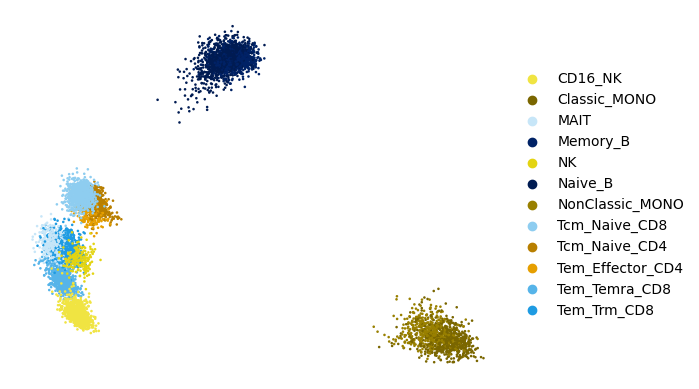

In [31]:
sc.pl.pca(adata, color='Sub_CT', palette=palette_minor_types, title='', frameon=False)

# Stats of nets

In [ ]:
if False:
    n_target = {}
    net_dict = {}
    for cell_type in cell_types:
        net = retrieve_net_consensus(cell_type=cell_type)
        net_dict[cell_type] = net
        n_target[cell_type] = net['target'].nunique()
    print(n_target)

    cell_type = 'MONO'
    net = net_dict[cell_type]
    c_outdegree = net.groupby('source').size().sort_values(ascending=False).head(20)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(2, 4))
    c_outdegree.plot(kind='barh')
    plt.xlabel('Source Gene')
    plt.title(f'Outdegree: {cell_type}')

# Datasets stats

In [46]:
from ciim.src.config import DISCOVERY_COHORTS, ALL_DATASETS, AGING_COHORTS
data_store = []
for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset, condition=None)
    
    for condition in adata.obs['condition'].unique():
        obs = adata[adata.obs['condition'] == condition].obs
        n_cells = obs['cell_count'].sum()
        n_donors = obs['donor_id'].nunique()
        n_age_donors = obs['donor_age'].nunique()
        if condition == 'healthy':
            condition = '-'
        data_store.append({'Cohort': dataset, 'Donors': n_donors, 'Cells': n_cells, 'Genes': adata.n_vars, 'Disease': condition})
    
df = pd.DataFrame(data_store)
df['Cohort'] = df['Cohort'].map(surrogate_names)
df.sort_values('Disease')

,Cohort,Donors,Cells,Genes,Disease
0,OneK1K,976,1233944,9100,-
1,ABF300,166,1897189,13152,-
2,SoundLife,96,13189039,15123,-
3,AIDA,623,1229847,12064,-
5,Perez,99,473142,10537,-
4,Perez,162,758325,10537,SLE


In [ ]:
df['only_healthy'] = df['Disease'].isin(['-'])
df_healthy = df[df['only_healthy']]
df_healthy['Cells'].sum(), df_healthy['Donors'].sum()

      Cohort  Donors     Cells  Genes Disease  only_healthy
0     OneK1K     976   1233944   9100       -          True
1     ABF300     166   1897189  13152       -          True
2  SoundLife      96  13189039  15123       -          True
3       AIDA     623   1229847  12064       -          True
5      Perez      99    473142  10537       -          True


(18023161, 1960)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Cells.png
Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Donors.png


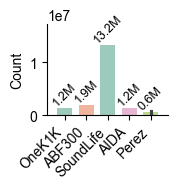

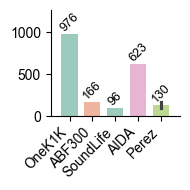

In [48]:
from ciim.src.config import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Cohort"], var_name="Metadata", value_name="Count")

cols = ['Cells', 'Donors']

for i, metadata in enumerate(cols):
    fig, ax = plt.subplots(1,1, figsize=(2, 2), sharex=False)
    # Create bar plot
    sns.barplot(data=df, x='Cohort', y=metadata, alpha=.7, ax=ax, hue='Cohort', width=.7, palette=palette_datasets_pretty, legend=False)
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        value = int(p.get_height())
        if value > 100000:
            value = f'{value/1e6:.1f}M'
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{value}',  # Text label
                ha='center', va='bottom', fontsize=9, rotation=45)  # Rotate 45 degrees

    # Formatting
    # ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()
    plt.tight_layout()

    plt.xticks(rotation=45)
    file_name = f'{PLOTS_DIR}/datasets_summary_{metadata}.png'
    print(f'Saving to {file_name}')
    plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

# plt.show()

In [49]:
# - overall gender coverage
datasets = AGING_COHORTS
gender_samples = {}
combined_df = []

for dataset in datasets:
    adata = retrieve_adata(dataset)
    adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F': 'Female', 'M': 'Male'}.get(name, name))
    df = df.drop_duplicates(subset=['donor_age'])
    df['dataset'] = dataset
    combined_df.append(df)

df = pd.concat(combined_df)

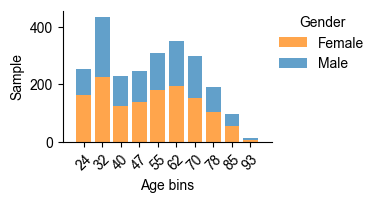

In [50]:
df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
df = df.drop_duplicates(subset=['donor_age'])
df = df[df['age']>20]
# Count occurrences of each sex within each age group
df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
# Pivot data for stacking
df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)
# Plot stacked bar chart
df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
df_binned = df_pivot.groupby('binned').sum() 
fig, ax = plt.subplots(figsize=(2.7, 1.7))
df_binned.plot(kind='bar', stacked=True, ax=ax, color=palette_genders, alpha=0.7, width=.8)


ax.set_xlabel("Age bins")
ax.set_ylabel("Sample")  
bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
ax.set_xticklabels(bin_midpoints)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - .5, x_max + .5) 
ax.legend(loc=[1.01, .5], frameon=False, title='Gender')
plt.savefig(f'{PLOTS_DIR}/datasets_age_distribution.png', bbox_inches='tight', dpi=300, transparent=True)


save to /vol/projects/jnourisa//output//plots//sex_distribution.png


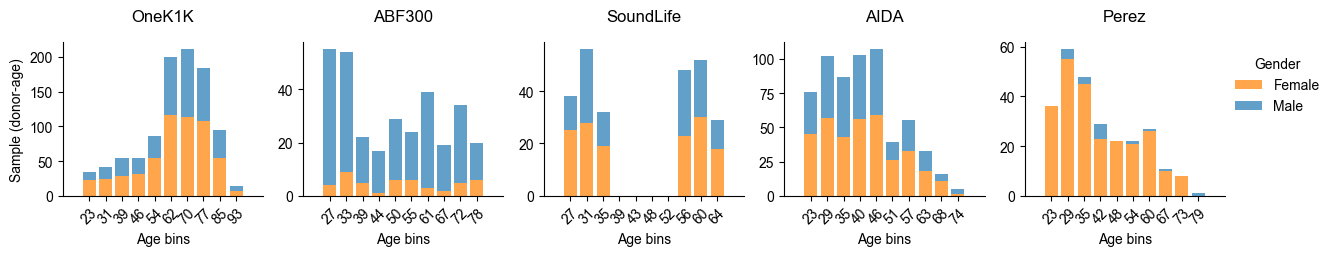

In [51]:
gender_samples = {}
def gender_distribution_plot(datasets):
    fig, axes = plt.subplots(1, len(datasets), figsize=(3*len(datasets), 2), sharey=False)
    for i, dataset in enumerate(datasets):
        adata = retrieve_adata(dataset)
        adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
        
        df = adata.obs.copy()
        df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
        df = df.drop_duplicates(subset=['donor_age'])

        # Count occurrences of each sex within each age group
        df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
        gender_samples[dataset] = {sex: df_count[df_count['sex']==sex]['count'].sum() for sex in ['Male', 'Female']}

        # Pivot data for stacking
        df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

        # Plot stacked bar chart
        df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
        df_binned = df_pivot.groupby('binned').sum() 
        df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_genders, alpha=0.7, width=.8)


        axes[i].set_xlabel("Age bins")
        axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
        axes[i].set_title(surrogate_names[dataset], pad=15)
        bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
        axes[i].set_xticklabels(bin_midpoints)

        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        x_min, x_max = axes[i].get_xlim()
        axes[i].set_xlim(x_min - 1, x_max + 1) 
        
        axes[i].get_legend().remove()
    axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')
    file_name = f'{PLOTS_DIR}/sex_distribution.png'
    print('save to' , file_name)
    plt.savefig(file_name, dpi=200, bbox_inches='tight', transparent=True)
    plt.show()
gender_distribution_plot(datasets)

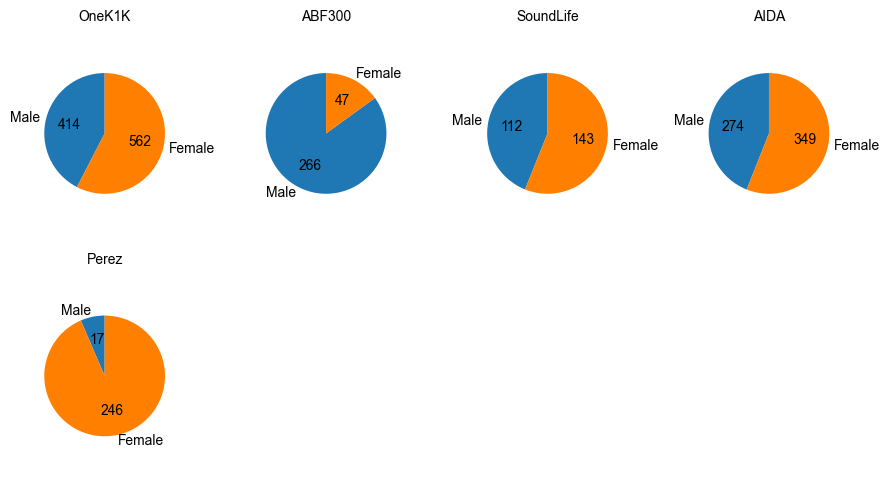

In [52]:
# Plotting pie charts
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
axes = axes.flatten()

for i, (dataset, counts) in enumerate(gender_samples.items()):
    labels = list(counts.keys())
    sizes = list(counts.values())
    # axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=palette_genders.values())
    axes[i].pie(sizes, labels=labels, autopct=lambda p: f'{int(round(p * sum(sizes) / 100))}', startangle=90, colors=palette_genders.values())
    
    axes[i].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    axes[i].set_title(surrogate_names[dataset], fontsize=10, weight='bold')

# Hide any unused subplots
for j in range(len(gender_samples), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Ethnicity

In [55]:
# Collect data from all datasets once
dataset_race_data = []
all_races = set()

for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset)
    if 'race' not in adata.obs.columns:
        adata.obs['race'] = 'European'
    
    df = (
        adata.obs
        .groupby("race")["donor_id"]
        .nunique()
        .reset_index(name="count")
    )
    
    # Filter races that have at least 2% of the population
    total_donors = df['count'].sum()
    df['percentage'] = (df['count'] / total_donors) * 100
    df = df[df['percentage'] >= 2.0]
    df = df.drop(columns=['percentage'])
    
    if len(df) > 0:  # Only add if there are races meeting the threshold
        dataset_race_data.append((dataset, df))
        all_races.update(df['race'])

Saving to /vol/projects/jnourisa//output//plots//race_composition.png


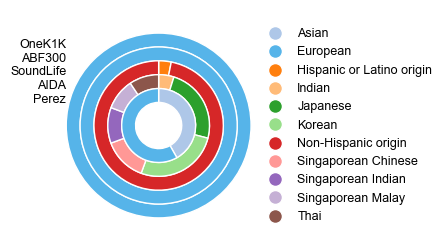

In [75]:

# Create figure with nested rings
fig, ax = plt.subplots(figsize=(4, 3))

# Map all unique races to distinct colors
all_races = sorted(all_races)
# Use a color palette with enough distinct colors
race_colors = {'European': colors_blind[1]}

color_palette = sns.color_palette("tab20", n_colors=len(all_races))
for race in all_races:
    if race in race_colors.keys():
        continue
    race_colors[race] = color_palette[len(race_colors)]


outer_radius = 1.0
ring_width = 0.15
dataset_labels = []

for i, (dataset, df) in enumerate(dataset_race_data):
    # Ensure colors match races correctly by sorting df by race to match color mapping
    df = df.sort_values('race')
    colors = [race_colors[r] for r in df["race"]]
    
    wedges, texts = ax.pie(
        df["count"],
        radius=outer_radius - i * ring_width,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=ring_width, edgecolor="white", linewidth=1),
    )
    dataset_labels.append((surrogate_names[dataset], outer_radius - i * ring_width - ring_width/2))
ax.set(aspect="equal")
for dataset_name, radius in dataset_labels:
    ax.text(-1, radius - 0.05, dataset_name, 
            ha='right', va='center', fontsize=9, weight='bold')
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=race_colors[race], markersize=10)
    for race in all_races
]
ax.legend(
    handles,
    all_races,
    # title="Ethnici",
    loc="center left",
    bbox_to_anchor=(.9, 0.5),
    frameon=False,
    fontsize=9,
    labelspacing=0.5
)
# plt.tight_layout()
file_name = f'{PLOTS_DIR}/race_composition.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

## Disease

  condition  count
0   healthy     99
1       SLE    162
Saving to /vol/projects/jnourisa//output//plots//disease_composition_perez_sle.png


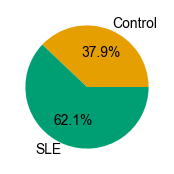

In [ ]:
dataset = 'perez_sle'
adata = retrieve_adata(dataset)
disease_info = adata.obs.groupby('condition')['donor_id'].nunique().reset_index(name='count')
print(disease_info)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
disease_info['condition'] = disease_info['condition'].replace({'healthy': 'Control'})
colors = {'Control': colors_blind[0], 'SLE': colors_blind[2]}
bb = ax.pie(disease_info['count'], labels=disease_info['condition'], autopct='%1.1f%%', colors=[colors[c] for c in disease_info['condition']], )
# plt.title(surrogate_names[dataset], pad=10)
file_name = f'{PLOTS_DIR}/disease_composition_{dataset}.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

Text(0.5, 1.0, 'C6: Covid')

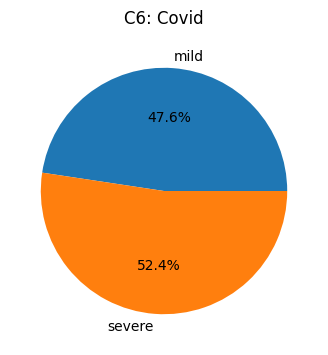

In [9]:
dataset = 'Covid_50MHH'
adata = retrieve_adata(dataset)

race_info = adata.obs.groupby('Max_WHO_Group')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['Max_WHO_Group'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

In [8]:
adata.obs.groupby(['cell_type', 'Max_WHO_Group']).size()

cell_type  Max_WHO_Group
B          mild             20
           severe           22
CD4T       mild             20
           severe           22
CD8T       mild             20
           severe           22
MONO       mild             20
           severe           22
NK         mild             20
           severe           22
dtype: int64

# Minor types rations

In [10]:
obs_dict = {dataset: ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets_all}

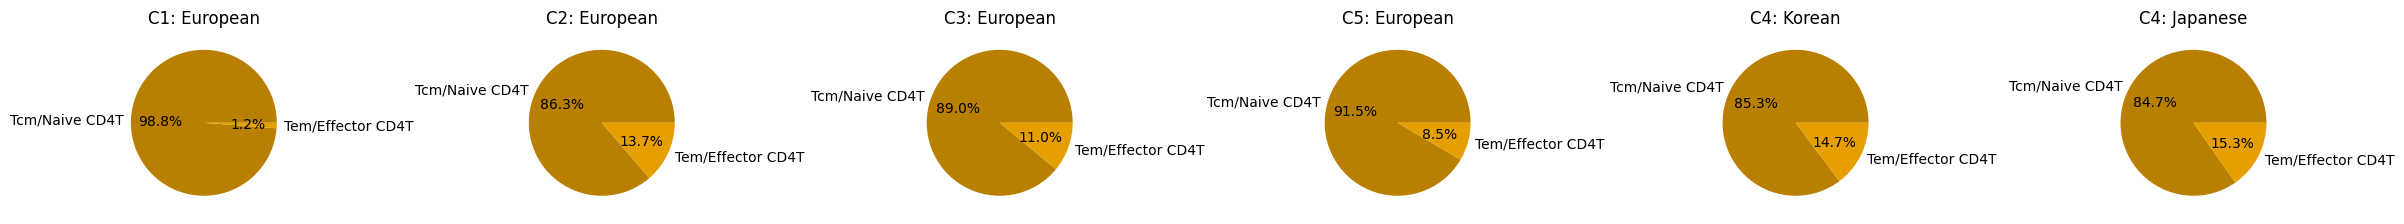

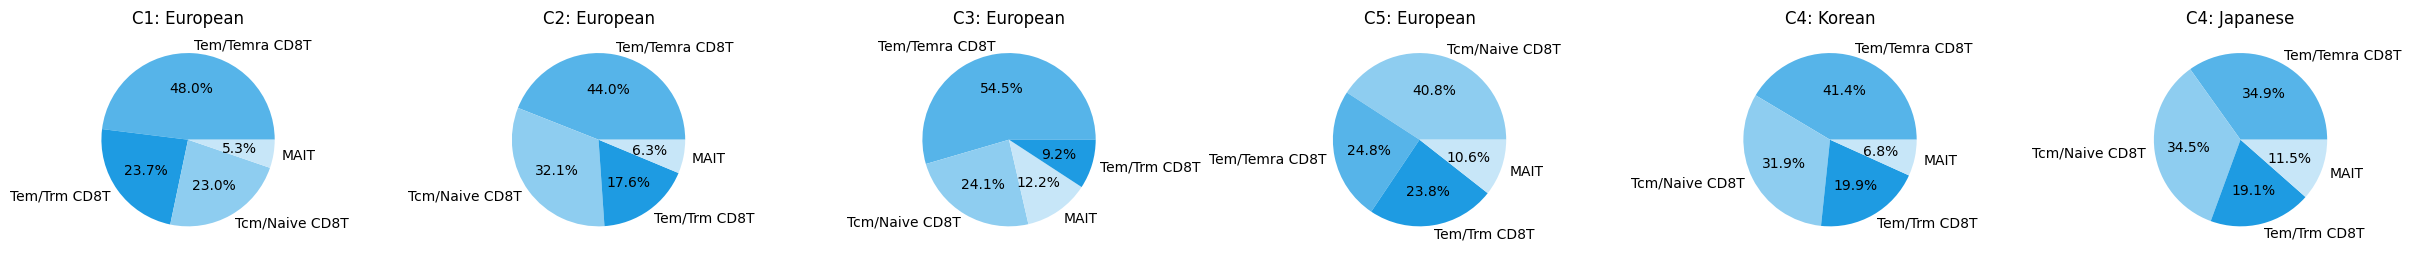

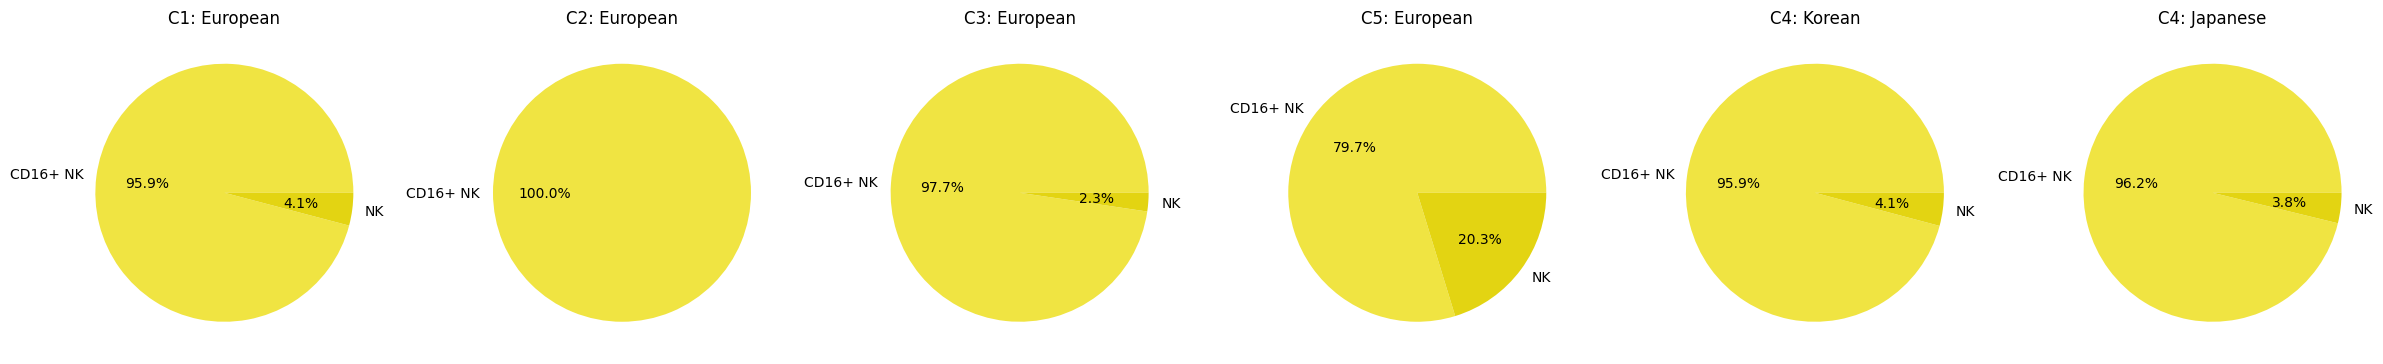

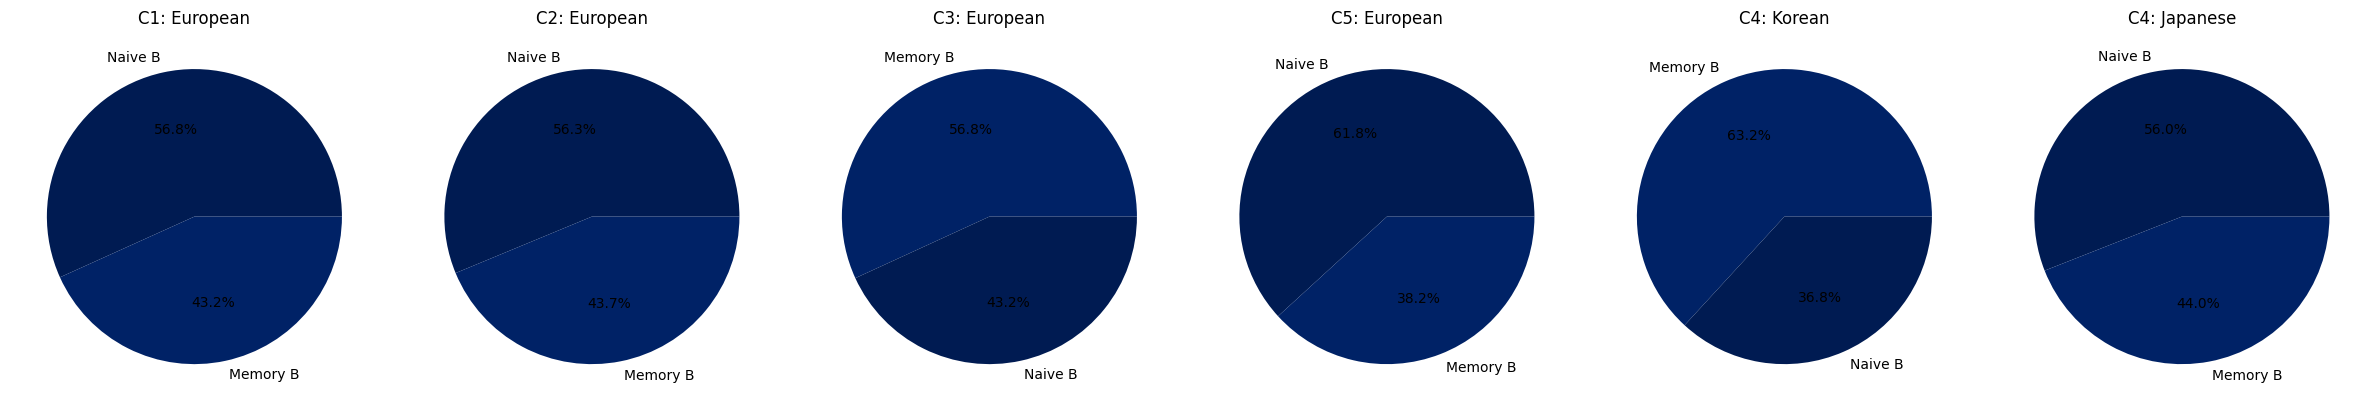

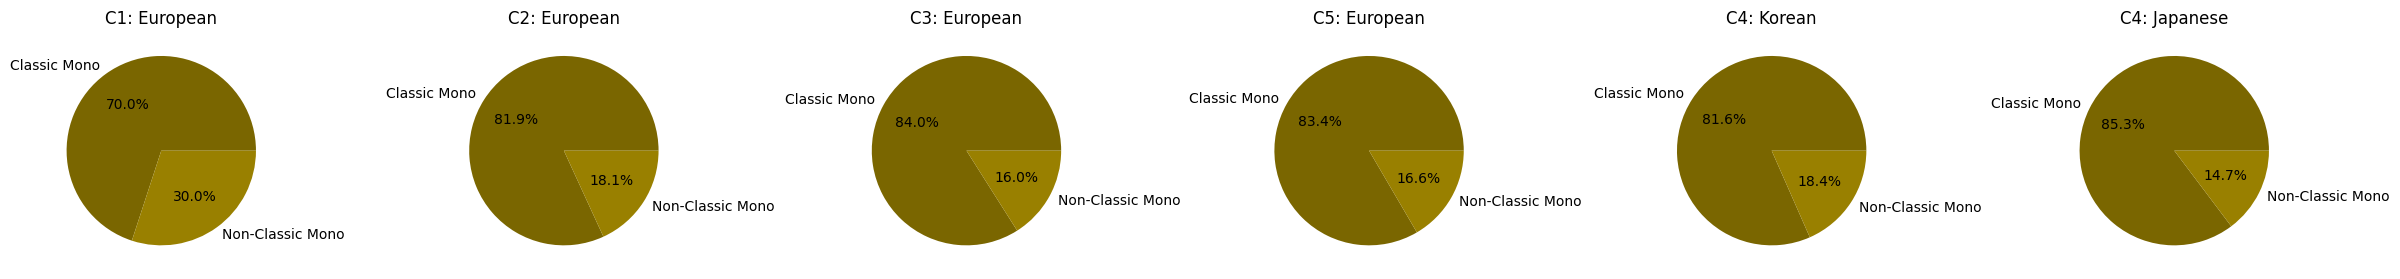

In [27]:
from ciim.src.config import minor_cell_types, palette_minor_types_pretty, mapping_minor_2_major, surrogate_names
def pieplot(df, ax):
    """Create a pie chart with mapped colors."""
    df = df.to_frame(name='count')  # Convert Series to DataFrame
    df.index.name = 'cell_type'
    colors = [palette_minor_types_pretty[cell] if cell in palette_minor_types_pretty else "#cccccc" for cell in df.index]
    df.plot(kind='pie', y='count', autopct='%1.1f%%', colors=colors, ax=ax, legend=False)
    ax.set_ylabel('')
datasets = datasets_all
for j, cell_type in enumerate(cell_types):
    fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 4))
    for i, dataset in enumerate(datasets):
        obs = obs_dict[dataset]
        obs = obs[obs['Sub_CT'].isin(minor_cell_types)] # keep only the valid names
        obs = obs[obs['Major_CT'] == cell_type]
        obs['Sub_CT'] = obs['Sub_CT'].astype(str)
        obs['Sub_CT'] = obs['Sub_CT'].apply(lambda name: surrogate_names.get(name, name))

        cell_type_counts = obs['Sub_CT'].value_counts()
        ax = axes[i]
        pieplot(cell_type_counts, ax)
        ax.set_title(surrogate_names[dataset])
    plt.tight_layout()

# Minor cell types frequency

In [39]:
def calculate_freq(obs):
    # - calculate frequency 
    obs['Sub_CT'] = obs['Sub_CT'].astype(str)
    subct_counts = obs.groupby(['donor_id', 'Sub_CT']).size().reset_index(name='count')
    total_counts = obs.groupby('donor_id').size().reset_index(name='total')
    freq = subct_counts.merge(total_counts, on='donor_id')
    freq['ratio'] = freq['count'] / freq['total']
    metadata_cols = ['donor_id', 'age', 'age_group']
    metadata = obs[metadata_cols].drop_duplicates()
    freq = freq.merge(metadata, on='donor_id', how='left')
    return freq

freq_store = []
for j, cell_type in enumerate(cell_types):
    for i, dataset in enumerate(datasets_all):
        obs = obs_dict[dataset]
        obs = obs[obs['cell_type'] == cell_type]
        freq = calculate_freq(obs)
        freq['dataset'] = dataset
        freq_store.append(freq)
freq_df = pd.concat(freq_store)

,donor_id,Sub_CT,count,total,ratio,age,age_group,dataset
126,1340,Naive_B,0,0,NaN,NaN,NaN,SLE_European
222,1811,Naive_B,0,0,NaN,NaN,NaN,SLE_European


['Tem_Trm_CD8', 'Tem_Temra_CD8', 'Tcm_Naive_CD8', 'MAIT']


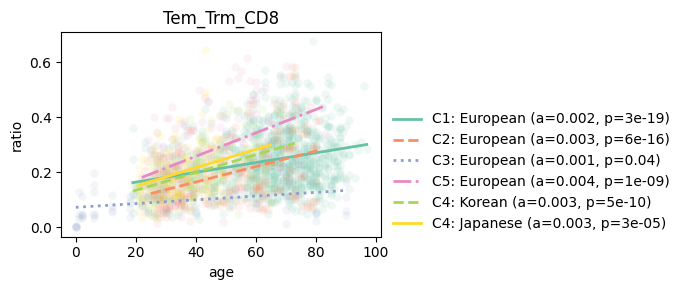

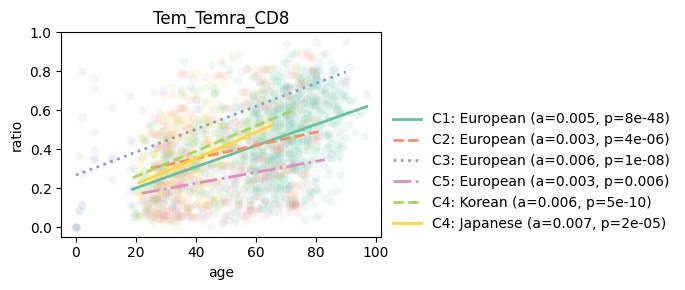

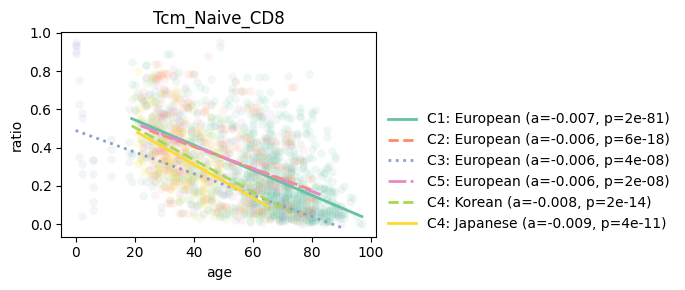

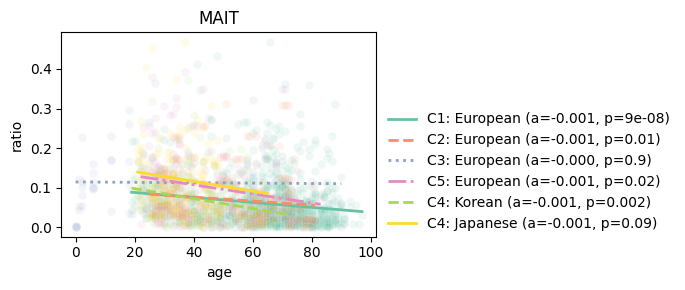

In [52]:
import statsmodels.api as sm
from scipy import stats

from ciim.src.config import mapping_major_2_minor

line_styles = ['-', '--', ':', '-.', '--']
line_styles+=line_styles
for cell_type in ['CD8T']:
    subtypes = mapping_major_2_minor[cell_type]
    print(subtypes)
    for i, subtype in enumerate(subtypes):
        fig, ax = plt.subplots(1, 1, figsize=(7, 3))
        # ax = axes[i]
        for j, dataset in enumerate(freq_df['dataset'].unique()):
            df_sub = freq_df[(freq_df['dataset'] == dataset)&(freq_df['Sub_CT'] == subtype)]
            sns.scatterplot(data=df_sub, x='age', y='ratio', color=palette_datasets[dataset], alpha=0.1, label=None, ax=ax)
            # Linear model
            X = sm.add_constant(df_sub['age'])
            df_sub = df_sub[~df_sub['ratio'].isna()]
            df_sub = df_sub[np.isfinite(df_sub['ratio'])]
            # Combine X and y into a single DataFrame temporarily
            df_model = pd.concat([X, df_sub['ratio']], axis=1)

            # Drop rows with any NaN or inf values
            df_model = df_model[np.isfinite(df_model).all(axis=1)]

            # Separate X and y again
            X_clean = df_model.drop(columns='ratio')
            y_clean = df_model['ratio']

            # Now fit the model
            model = sm.OLS(y_clean, X_clean).fit()
            slope = model.params['age']
            pval = model.pvalues['age']
            
            # Predict line
            x_vals = df_sub['age'].sort_values()
            y_vals = model.predict(sm.add_constant(x_vals))
            
            ax.plot(x_vals, y_vals, linestyle=line_styles[j], color=palette_datasets[dataset], label=f"{surrogate_names[dataset]} (a={slope:.3f}, p={pval:.1g})", linewidth=2)
        ax.legend(loc=(1.02, 0), frameon=False)
        ax.set_title(subtype)
        plt.tight_layout()

# GRNs

## Compare nets


In [10]:
from ciim.src.utils.util import retrieve_net
if True:
    net_store = []
    for cell_type in CELL_TYPES:
        for dataset in DISCOVERY_COHORTS:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)


net: CD4T onek1k  (8458, 6)
net: CD4T abf300  (18690, 6)
net: CD4T aida  (41608, 6)


net: CD4T perez_sle  (17142, 6)
net: CD8T onek1k  (12819, 6)
net: CD8T abf300  (46853, 6)
net: CD8T aida  (122141, 6)
net: CD8T perez_sle  (9208, 6)
net: NK onek1k  (2233, 6)
net: NK abf300  (11764, 6)
net: NK aida  (32322, 6)
net: NK perez_sle  (2632, 6)
net: B onek1k  (165818, 6)
net: B abf300  (36563, 6)
net: B aida  (73882, 6)
net: B perez_sle  (11304, 6)
net: MONO onek1k  (87189, 6)
net: MONO abf300  (107501, 6)
net: MONO aida  (284906, 6)
net: MONO perez_sle  (25912, 6)


['AIDA', 'OneK1K', 'ABF300', 'Perez']


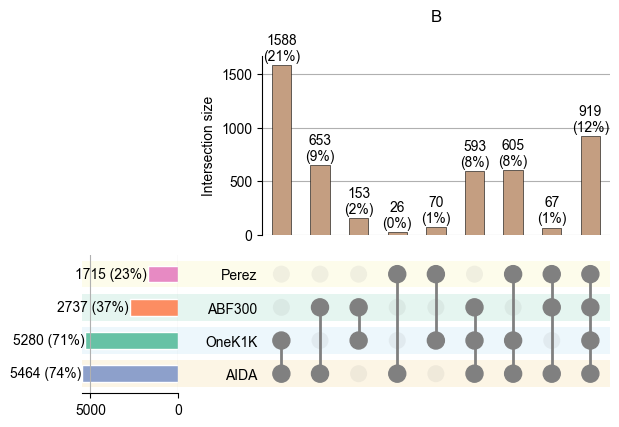

In [16]:
from grn_benchmark.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    to_show = 'target'
    cell_type = 'B'

    if to_show=='source':
        min_subset_size=10
        min_degree=1
    if to_show=='target':
        min_subset_size=10
        min_degree=2
    if to_show=='edge':
        min_subset_size=8000
        min_degree=2


    
    nets = nets_all[nets_all['cell_type']==cell_type]
    df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

    interaction_df = create_interaction_df(df_dict)
    interaction_df.columns = interaction_df.columns.map(surrogate_names)
    aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
    plt.title(cell_type, y=1.15, weight='bold')